In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

In [ ]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  #Hour given in UTC time

In [4]:
env.set_atmospheric_model(type="Forecast", file="GFS")

In [ ]:
motor = SolidMotor(
    thrust_source="Cesaroni_6026M1670-P.eng",  #Path to the eng file relative to this file 
    dry_mass=26.105,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

In [6]:
my_rocket = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag=.1,
    power_on_drag=.1,
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

In [7]:
my_rocket.add_motor(motor, position=-1.255)

In [8]:
nose_cone = my_rocket.add_nose(
    length=61, kind="von karman", position=1.278
)

fin_set = my_rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.305,
    tip_chord=0.178,
    span=0.178,
    position=-1.04956,
    cant_angle=0,
    airfoil=0,
)

tail = my_rocket.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

In [9]:
test_flight = Flight(
    rocket=my_rocket, environment=env, rail_length=5.2, inclination=85, heading=0
    )

In [ ]:
#Need quantinarian of the 4 scalers, convert those into the 3 eulor angles// OR just keep 3 eulor angles
#Need a CSV on a 100hz with the following information
#Acceleartion on all three axis, Gyroscopic on all three axis, and absolute orientation
#Question: For the 4x4 matrix, does he need the 4 scalers or the entire 4x4 matrix???

In [ ]:
#First we extract raw solution as NumPy array
solution_array = test_flight.solution_array  # shape (n_time_steps, 14)

#Then we resample at 100 Hz
t_full = solution_array[:, 0]
t_100hz = np.arange(0, t_full[-1], 0.01)  # 100 Hz → dt = 0.01 s


In [ ]:
#Interpolate all columns to 100 Hz
solution_100hz = np.zeros((len(t_100hz), 14))
for i in range(14):
    solution_100hz[:, i] = np.interp(t_100hz, t_full, solution_array[:, i])

# Now we extract components
velocity = solution_100hz[:, 4:7]       # vx, vy, vz
angular_velocities = solution_100hz[:, 11:14]  # w1, w2, w3
quaternions = solution_100hz[:, 7:11]   # e0, e1, e2, e3

#Compute acceleration (finite difference)
acceleration = np.gradient(velocity, 0.01, axis=0)  # m/s²

In [ ]:
#Here we convert quaternion → Euler angles (roll, pitch, yaw) in degrees
def quat_to_euler_deg(q):
    q0, q1, q2, q3 = q
    sinr_cosp = 2 * (q0*q1 + q2*q3)
    cosr_cosp = 1 - 2 * (q1**2 + q2**2)
    roll = np.degrees(np.arctan2(sinr_cosp, cosr_cosp))

    sinp = 2 * (q0*q2 - q3*q1)
    pitch = np.degrees(np.arcsin(np.clip(sinp, -1.0, 1.0)))

    siny_cosp = 2 * (q0*q3 + q1*q2)
    cosy_cosp = 1 - 2 * (q2**2 + q3**2)
    yaw = np.degrees(np.arctan2(siny_cosp, cosy_cosp))

    return np.array([roll, pitch, yaw])

euler_angles = np.array([quat_to_euler_deg(q) for q in quaternions])

In [ ]:
#Build DataFrame
df = pd.DataFrame({
    "time": t_100hz,
    "ax": acceleration[:, 0],
    "ay": acceleration[:, 1],
    "az": acceleration[:, 2],
    "wx": angular_velocities[:, 0],
    "wy": angular_velocities[:, 1],
    "wz": angular_velocities[:, 2],
    "roll": euler_angles[:, 0],
    "pitch": euler_angles[:, 1],
    "yaw": euler_angles[:, 2],
    "e0": quaternions[:, 0],
    "e1": quaternions[:, 1],
    "e2": quaternions[:, 2],
    "e3": quaternions[:, 3],
})


In [ ]:
# Export the Information to a CSV
# The format is:
# Time (100hz) - Accelerations (ax, ay, az) - Angular Velocities (wx, wy, wz) - Euler Anglers (roll, pitch, yaw) - Quaternions (e0, e1, e2, e3)
df.to_csv("test_data.csv", index=False)

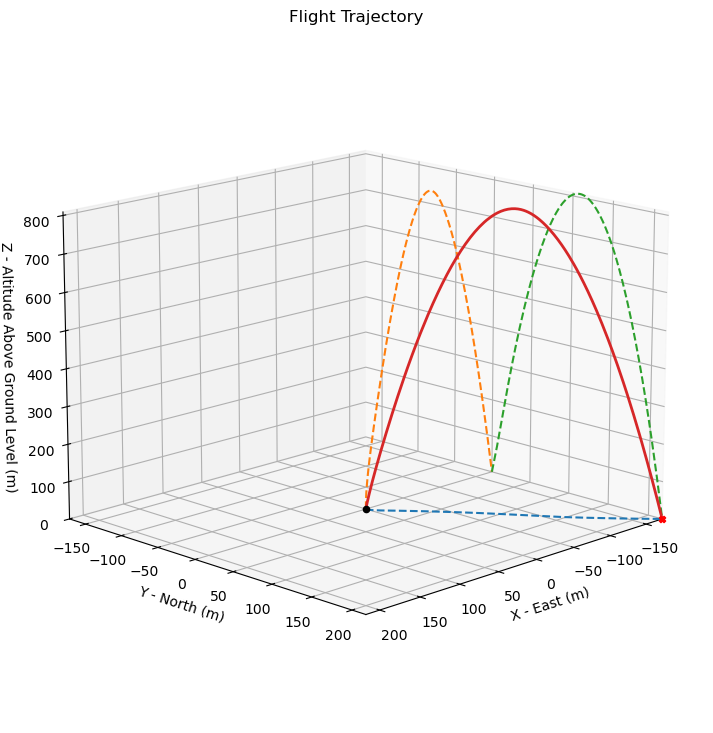

In [ ]:
#Here's what the flight should look like on his end
test_flight.plots.trajectory_3d()